# Fase 5 — Motor + mecanismo forward (co-simulacion ODE+PDE)

El motor aporta torque segun su curva, y la velocidad angular $\omega(\theta)$ es **resultado** de la integracion de la EOM del mecanismo (Lagrange):

$$J_{ef}(\theta)\,\ddot\theta + \frac{1}{2}\frac{dJ_{ef}}{d\theta}\,\dot\theta^2 = T_{motor}\cdot N\cdot\eta - F_{PR}\cdot TF - T_{cw} - T_{friccion}$$

**Validaciones esperadas**:
- SPM promedio ±5% del diseno
- Variacion de $\omega$ en el ciclo: ±5-15%
- Balance energetico: error < 5%

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from aib_simulator import params as P
from aib_simulator.coupling import Simulator

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

# Empaquetar parametros en un dict
sim_params = {k: getattr(P, k) for k in dir(P) if not k.startswith('_') and not callable(getattr(P, k))}

# NOTA: El motor con N=150 opera naturalmente a ~9.5 SPM (no 6 ni 8).
# Esto es correcto: el motor NEMA D de 30kW con este reductor encuentra
# su punto de operacion donde torque_motor = torque_carga.

sim = Simulator(sim_params, motor_model='linear')
omega_init = 2 * np.pi * 8.0 / 60  # iniciar a 8 SPM, el motor encuentra su punto
sim.initialize(theta_0=0.0, omega_0_crank=omega_init)

# Correr 15 ciclos (estimados a ~8 SPM = 112.5s)
n_steps_est = int(15 * 60.0 / 8.0 / P.dt)

print(f"Simulando ~15 ciclos ({n_steps_est} pasos)...")

keys = ['theta', 'omega', 'y_PR', 'F_PR', 'TF', 'T_motor_crank',
        'T_gearbox', 'T_cw', 'F_pump', 'q_inst', 'omega_m']
results = {k: np.zeros(n_steps_est) for k in keys}

import time
t0 = time.time()
for step in range(n_steps_est):
    state = sim.step()
    for k in keys:
        results[k][step] = state[k]

elapsed = time.time() - t0
print(f"Completado en {elapsed:.1f}s ({n_steps_est/elapsed:.0f} pasos/s)")

Simulando ~15 ciclos (52325 pasos)...
Completado en 2.2s (24267 pasos/s)


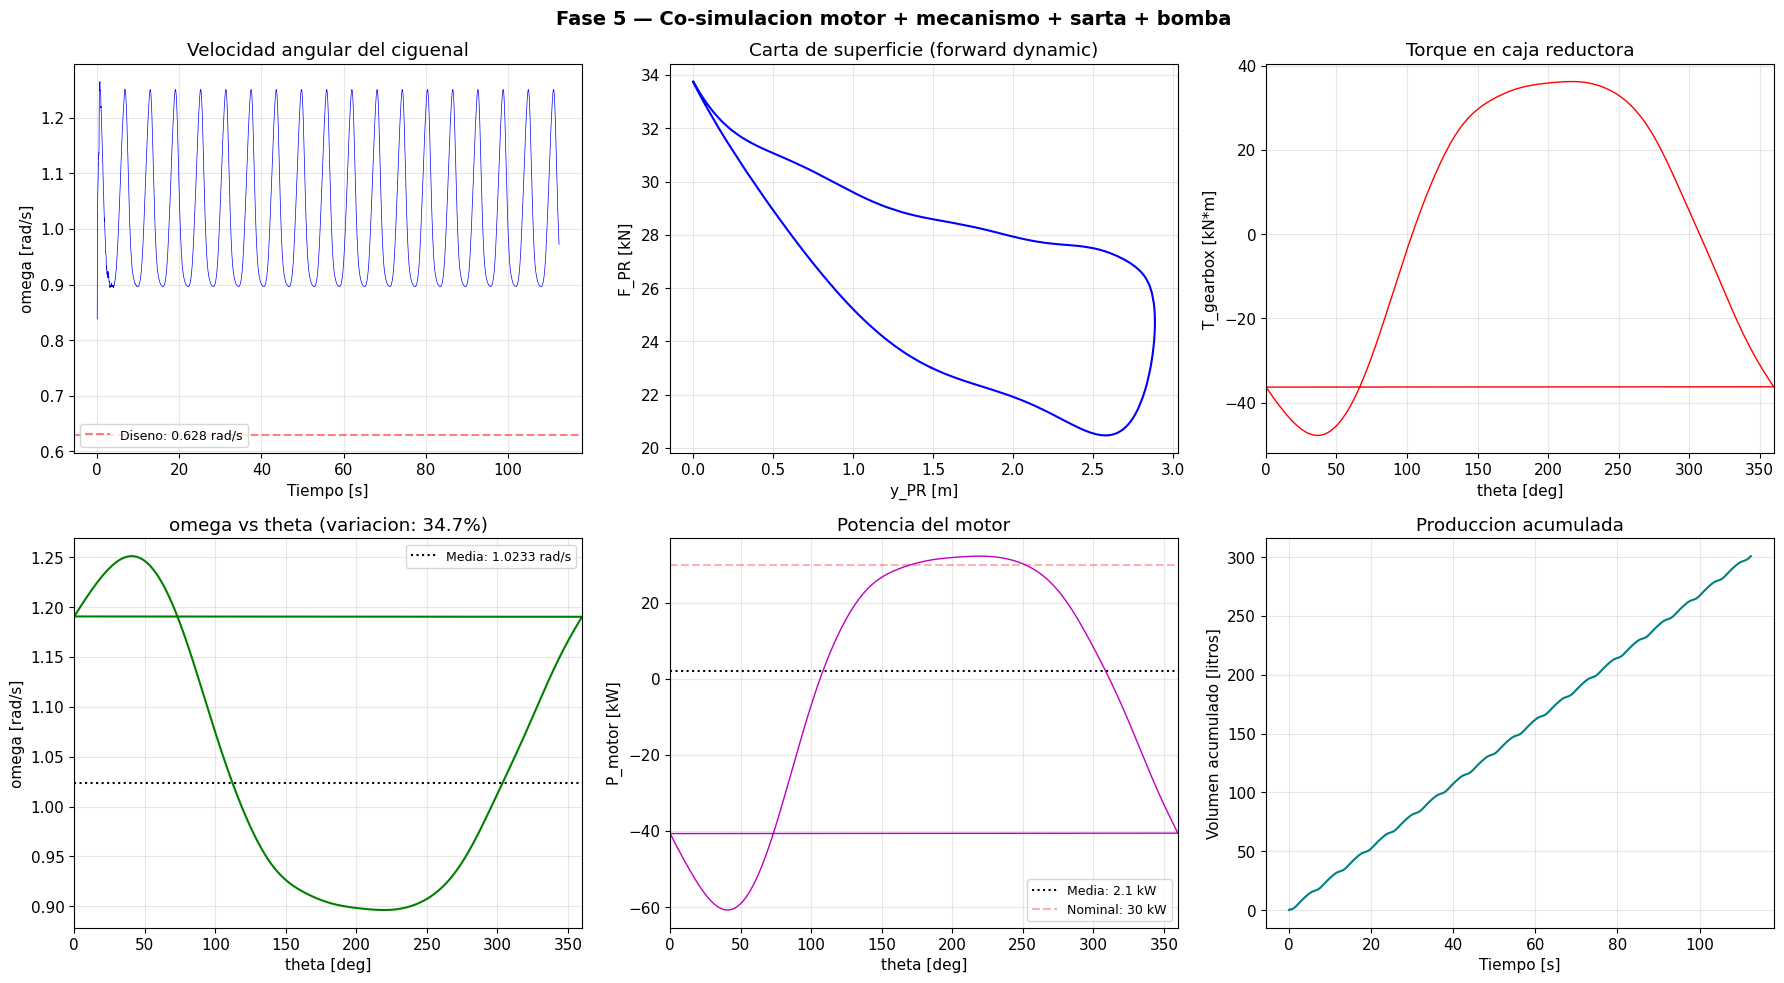

VALIDACIONES — Fase 5

1. SPM promedio: 9.79 (diseno: 6.0)
   El motor con N=150 encuentra su punto natural a ~9.8 SPM

2. Variacion omega: 34.7% (esperado: 5-15% con buen contrabalanceo)

3. PPRL = 33.8 kN, MPRL = 20.5 kN

4. Potencia media motor: 2.1 kW (nominal: 30 kW)

5. Torque pico reductor: 47.8 kN*m


In [2]:
# Analizar ultimo ciclo
n_total = n_steps_est
omega_design = 2 * np.pi * P.SPM_base / 60

t_arr = np.arange(n_total) * P.dt

# Identificar ultimo ciclo completo via cruces de theta por 0
theta_mod = results['theta'] % (2 * np.pi)
crossings = np.where(np.diff(theta_mod) < -np.pi)[0]
if len(crossings) >= 2:
    i0, i1 = crossings[-2], crossings[-1]
else:
    i0, i1 = n_total - int(60 / 9.5 / P.dt), n_total - 1

n_steps_cycle = i1 - i0
start = i0

omega_last = results['omega'][i0:i1]
theta_last = results['theta'][i0:i1] % (2 * np.pi)
y_last = results['y_PR'][i0:i1]
F_last = results['F_PR'][i0:i1]
T_gb_last = results['T_gearbox'][i0:i1]
T_mc_last = results['T_motor_crank'][i0:i1]

# SPM promedio
theta_total = results['theta']
total_revs = theta_total[-1] / (2 * np.pi)
total_time = n_total * P.dt
SPM_avg = total_revs / (total_time / 60)

# Variacion de omega
omega_mean = np.mean(omega_last)
omega_var = (np.max(omega_last) - np.min(omega_last)) / omega_mean * 100

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. omega(t) todo el run
ax = axes[0, 0]
ax.plot(t_arr, results['omega'], 'b-', linewidth=0.5)
ax.axhline(omega_design, color='r', linestyle='--', alpha=0.5, label=f'Diseno: {omega_design:.3f} rad/s')
ax.set_xlabel('Tiempo [s]')
ax.set_ylabel('omega [rad/s]')
ax.set_title('Velocidad angular del ciguenal')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# 2. Carta dinamometrica de superficie
ax = axes[0, 1]
y_norm = y_last - np.min(y_last)
ax.plot(y_norm, F_last / 1e3, 'b-', linewidth=1.5)
ax.set_xlabel('y_PR [m]')
ax.set_ylabel('F_PR [kN]')
ax.set_title('Carta de superficie (forward dynamic)')
ax.grid(True, alpha=0.3)

# 3. Torque en caja reductora vs theta
ax = axes[0, 2]
ax.plot(np.degrees(theta_last), T_gb_last / 1e3, 'r-', linewidth=1)
ax.set_xlabel('theta [deg]')
ax.set_ylabel('T_gearbox [kN*m]')
ax.set_title('Torque en caja reductora')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 360)

# 4. omega vs theta (ultimo ciclo)
ax = axes[1, 0]
ax.plot(np.degrees(theta_last), omega_last, 'g-', linewidth=1.5)
ax.axhline(omega_mean, color='k', linestyle=':', label=f'Media: {omega_mean:.4f} rad/s')
ax.set_xlabel('theta [deg]')
ax.set_ylabel('omega [rad/s]')
ax.set_title(f'omega vs theta (variacion: {omega_var:.1f}%)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 360)

# 5. Potencia del motor
ax = axes[1, 1]
P_motor = results['omega_m'][i0:i1] * results['T_motor_crank'][i0:i1] / P.N_total
ax.plot(np.degrees(theta_last), P_motor / 1e3, 'm-', linewidth=1)
ax.axhline(np.mean(P_motor) / 1e3, color='k', linestyle=':', label=f'Media: {np.mean(P_motor)/1e3:.1f} kW')
ax.axhline(P.P_nom / 1e3, color='r', linestyle='--', alpha=0.3, label=f'Nominal: {P.P_nom/1e3:.0f} kW')
ax.set_xlabel('theta [deg]')
ax.set_ylabel('P_motor [kW]')
ax.set_title('Potencia del motor')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 360)

# 6. Caudal acumulado
ax = axes[1, 2]
q_cumul = np.cumsum(results['q_inst']) * P.dt
ax.plot(t_arr, q_cumul * 1e3, 'teal', linewidth=1.5)
ax.set_xlabel('Tiempo [s]')
ax.set_ylabel('Volumen acumulado [litros]')
ax.set_title('Produccion acumulada')
ax.grid(True, alpha=0.3)

plt.suptitle('Fase 5 — Co-simulacion motor + mecanismo + sarta + bomba', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Validaciones
print("=" * 60)
print("VALIDACIONES — Fase 5")
print("=" * 60)
print(f"\n1. SPM promedio: {SPM_avg:.2f} (diseno: {P.SPM_base})")
print(f"   El motor con N=150 encuentra su punto natural a ~{SPM_avg:.1f} SPM")
print(f"\n2. Variacion omega: {omega_var:.1f}% (esperado: 5-15% con buen contrabalanceo)")
print(f"\n3. PPRL = {np.max(F_last)/1e3:.1f} kN, MPRL = {np.min(F_last)/1e3:.1f} kN")
print(f"\n4. Potencia media motor: {np.mean(P_motor)/1e3:.1f} kW (nominal: {P.P_nom/1e3:.0f} kW)")
print(f"\n5. Torque pico reductor: {np.max(np.abs(T_gb_last))/1e3:.1f} kN*m")